In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
from multiprocessing import Pool

import matplotlib.pyplot as plt
%matplotlib widget

import seaborn as sns

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.metrics import f1_score, balanced_accuracy_score, average_precision_score, confusion_matrix
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import minimize_scalar

from tqdm.auto import tqdm
tqdm.pandas()

THRESHOLD = 0.29

In [2]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '18_humenv_dhw_cat_pa-2025-07-11_16-53-preds' / 'predictions-probs.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

predictions_sr = (predictions > THRESHOLD).sum(axis=1)
predictions_prev = (predictions > THRESHOLD).sum(axis=0)

In [3]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
fulldf = pd.read_csv(p, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
targets = fulldf.loc[fulldf['subset'] == 'test', predictions.columns]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

## Species richness threshold

In [22]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '18_humenv_dhw_cat_pa-2025-07-11_16-53-preds' / 'predictions_trainval.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

In [23]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
fulldf = pd.read_csv(p, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
targets = fulldf.loc[fulldf['subset'] != 'test', predictions.columns]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

In [24]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    return np.abs(sr.mean() - target_sr.mean())


threshold = minimize_scalar(rvalue, args=(predictions, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.28981360140972007


## Outputs visualization

#### Species richness

In [4]:
print(linregress(targets_sr, predictions_sr))

LinregressResult(slope=0.4089906438979969, intercept=4.256380532859874, rvalue=0.6059153605960409, pvalue=0.0, stderr=0.007631519658214615, intercept_stderr=0.21761607427228566)


In [5]:
fig = px.scatter(
    x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
    marginal_y='violin', marginal_x='violin'
)
# fig = px.scatter(
#     x=targets_sr, y=predictions_sr,
#     marginal_y='violin', marginal_x='violin'
# )
fig.update_layout(width=800, height=800)
fig.show()

<Axes: xlabel='None', ylabel='None'>

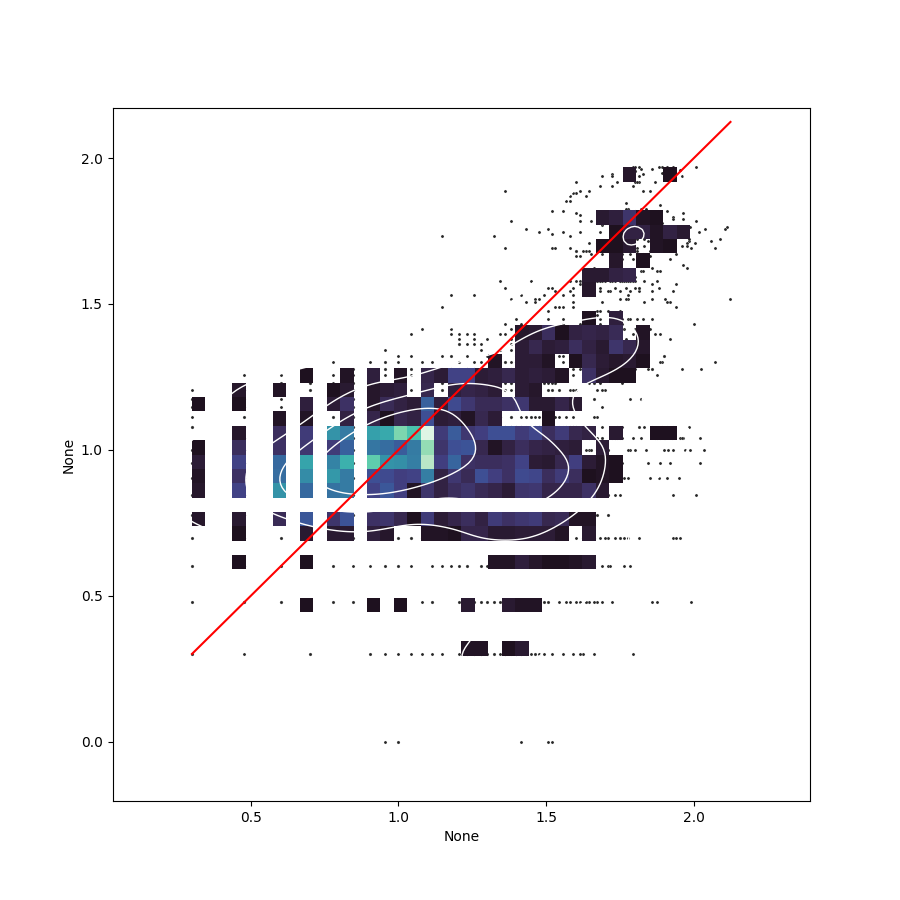

In [6]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

#### Threshold optimization

In [14]:
# Find best threshold for f1

def nf1(thres):
      
    f1 = f1_score(targets_pres.to_numpy().flatten(),
                 (predictions>thres).to_numpy().flatten())

    return -f1


threshold = minimize_scalar(nf1, method='Bounded', bounds=(0,1))['x']
print(threshold)

0.16155175966821655


#### Confusion matrix

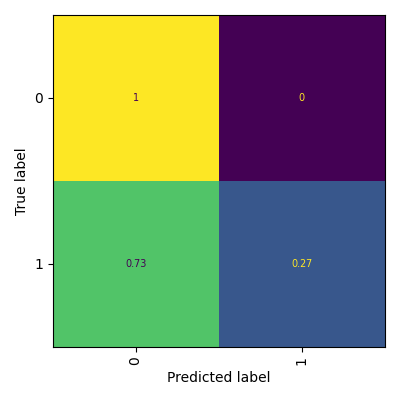

In [29]:
cm = confusion_matrix(targets_pres.to_numpy().flatten(), (predictions>THRESHOLD).to_numpy().flatten(), labels=(0,1), normalize = 'true')
cm = cm.round(2)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=(0,1))
disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax)
plt.tight_layout()
plt.show()
#plt.savefig(pred_path.parent / 'confusion_matrix.png')


#### F1 by site

In [30]:
# F1 by site

f1scores = []
test_df = fulldf[fulldf['subset'] == 'test']

for site in test_df['site_code'].unique():
    surveys = test_df[test_df['site_code'] == site].index
    lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
    preds = (predictions > THRESHOLD).astype(float).loc[surveys].to_numpy().flatten()
    targets = (test_df != 0).astype(float).loc[surveys, predictions.columns].to_numpy().flatten()
    f1 = f1_score(targets, preds)
    f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

pd.DataFrame(f1scores).to_csv(pred_path.parent / 'f1_by_site.csv')


In [31]:
pd.DataFrame(f1scores).describe()

,f1,lat,lon
count,412.000000,412.000000,412.000000
mean,0.331305,-29.308932,142.045558
std,0.177800,9.823767,12.718351
min,0.000000,-41.150000,113.340000
25%,0.205683,-38.180000,144.310000
50%,0.348051,-32.020000,146.115000
75%,0.468616,-20.800000,149.262500
max,0.750000,-10.500000,153.630000


#### Embedding

In [3]:
emb = np.load(output_path / '23_humenv_dhw_best30_pa-2025-07-01_11-07-embed' / 'embedding.npy')

to_explain = predictions.T

NameError: name 'output_path' is not defined

In [11]:
from sklearn.decomposition import PCA

test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=3)
pca.fit(to_explain)
print(pca.explained_variance_ratio_)
pca_emb = pca.transform(to_explain)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2', 'pc3'], index = predictions.columns) #test_df.index)
#pca_pd['tsr'] = np.log (1+targets_sr)
#pca_pd['psr'] = np.log (1+predictions_sr)



[0.47717064 0.33688734 0.0765714 ]


In [13]:
import plotly.express as px

fig = px.scatter_3d(pca_pd, x='pc1', y='pc2', z='pc3', height = 1200, color = predictions_prev) #, color='tsr')
fig.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 8
clustering = AgglomerativeClustering(n_clusters=n_clusters)
cluster_labels = clustering.fit_predict(pca_pd[['pc1', 'pc2', 'pc3']])
pca_pd['cluster_label'] = cluster_labels


In [20]:
import plotly.express as px
fig = px.scatter_3d(pca_pd, x='pc1', y='pc2', z='pc3', color='cluster_label', height = 1200)

fig.update_scenes(xaxis_title_font_color="blue",
                  xaxis_tickfont_color="blue",
                  yaxis_title_font_color="red",
                  yaxis_tickfont_color="red",  
                  zaxis_title_font_color="green",
                  zaxis_tickfont_color="green",)
fig.show()

In [29]:
points = pd.melt(predictions, ignore_index = False).merge(pca_pd, left_on='variable', right_index=True).where(lambda x: x['value'] > 0.1).dropna()
df = points.merge(test_df[['site_code', 'latitude', 'longitude', 'survey_date']], left_index=True, right_index=True)

In [ ]:
#df = pd.concat([pca_pd, test_df[['site_code', 'latitude', 'longitude', 'survey_date']]], axis=1)

fig = px.scatter_geo(df, lat="latitude", lon="longitude",
                     color='cluster_label',
                     fitbounds='locations',
                     height=800,
                     #size = 'tsr',
                     opacity = 0.01
                     )

fig.show()

In [39]:
to_export = pd.concat([pca_pd, test_df[['site_code', 'latitude', 'longitude', 'survey_date']]], axis=1)
to_export.to_csv('~/Desktop/pca.csv')

## Best species

#### Extraction

In [32]:
# Calculate average precision

ap = average_precision_score(targets_pres.to_numpy(), predictions.to_numpy(), average=None)

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/data/venvs/copmarine/lib/python3.10/site-pac

In [33]:
# aps = pd.DataFrame({"AP":ap, "prev":(targets[predictions.columns] > 0).sum(axis=0)}, index=predictions.columns)
aps = pd.DataFrame({"AP":ap}, index=predictions.columns)
aps.sort_values(ascending=False, by ='AP', inplace = True)
aps.to_csv(pred_path.parent / 'aps-sorted.csv')

In [34]:
aps.describe()

,AP
count,1796.000000
mean,0.076599
std,0.143047
min,-0.000000
25%,-0.000000
50%,0.010299
75%,0.084594
max,1.000000


In [98]:
baseline_aps = pd.read_csv(pred_path.parent / 'aps-sorted.csv')

In [ ]:
#
# aps = aps.reset_index()


fig = px.line(x=aps.index,
                 y=aps['AP'],
                 width=800,
                 height=600)

fig.update_traces(line_color='red')
# fig.update_yaxes(   scaleanchor="x",
#                     scaleratio=1)

fig.add_traces(list(px.line(x=baseline_aps.index,
                 y=baseline_aps['AP'],
                 width=800,
                 height=600,
                 labels='Baseline').select_traces()))

fig.show()

# Blue : Baseline
# Red : New

In [52]:
aps['logprev'] = np.log10(1+aps['prev'])
fig = px.scatter(aps,
                 x='logprev',
                 y='AP',
                 text='prev',
                 template='simple_white',
                 width=800,
                 height=600)

fig.show()

In [12]:
# Save to file

best_species = aps.iloc[0:100]
best_pred_path = pred_path.parent / 'predictions-probs-best100.csv'

df1 = predictions[list(best_species.index)]
df2 = fulldf[['latitude', 'longitude', 'depth', 'eventDate']]
pd.concat([df2, df1], axis=1, join="inner").to_csv(best_pred_path)

#### Create input files for additional training (best10 modality)

In [10]:
bestpredspath = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/best30')

def save_line(row):
    np.save(bestpredspath / f"{row.name}.npy", row.values.astype(float))

In [11]:
best_pred_path = pred_path.parent / 'predictions-probs-best30.csv'
best_pred = pd.read_csv(best_pred_path, index_col='survey_id')
best_species = best_pred.columns[4:]
groundtruth = fulldf.loc[fulldf['subset'] != 'test' , best_species] > 0
to_save = pd.concat([groundtruth, best_pred[best_species]])
to_save.progress_apply(save_line, axis=1)

  0%|          | 0/27437 [00:00<?, ?it/s]

survey_id
923400045    None
923400036    None
923400037    None
923400043    None
923402703    None
             ... 
712300818    None
712301159    None
712301158    None
712301157    None
712301156    None
Length: 27437, dtype: object

In [ ]:
print(best_species)

#### Plotting

In [ ]:
# Species-specific confusion matrices

i = 0
for s in list(best_species.index):

    PrecisionRecallDisplay.from_predictions(targets_pres[s].to_numpy(), predictions[s].to_numpy())
    plt.savefig(pred_path.parent / 'PR-curves' / f"{s}.png")

    # numbins = 2

    # cm = confusion_matrix((targets[s]>0).to_numpy().astype(int), (predictions[s]>0.5).to_numpy().astype(int), labels=range(numbins), normalize = 'true')
    # cm = cm.round(3)

    # fig, ax = plt.subplots(figsize=(6, 6))
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"absent (N={len(targets) - targets_prev[s]})", f"present (N={targets_prev[s]})"])
    # disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax, cmap = 'Blues')
    # disp.ax_.set_title(f"{s} - AP: {best_species.loc[s,'AP']:.2f},\n prevalence = {targets_prev[s]}")
    # plt.tight_layout()
    # plt.savefig(pred_path.parent / 'cm' / f'{i}_{s}.png')
    # #plt.show()
    # i += 1

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species_300.csv', index_col = 0)
best_species['genus'] = best_species.index.to_series().apply(lambda x: str(x).split()[0])

px.scatter(best_species, x='prev', y='AP', color='genus')

## Interpretability

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species.csv', index_col = 0)
species = list(best_species.index)
ig_path = pred_path.parent / 'integrated_gradients'

labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

#### Per variable density

In [ ]:
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if fulldf.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(pred_path.parent / "ig_densities" / f"{s}.png")

In [ ]:
with Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

#### Summary chart

In [ ]:
series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()

## Compare checkpoints

In [45]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-16_14-50-preds' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',
               '23_humenv_dhw_best30_pa-2025-05-21_09-48-preds': 'Envhum+DHW+Best30',
               }

checkpoints = {'18_humenv_dhw_cat_pa-2025-07-07_16-55-preds': 0,
               #'18_humenv_dhw_cat_pa-2025-07-02_16-41-preds': .011111,
            #   '18_humenv_dhw_cat_pa-2025-07-08_09-39-preds': .01,
            #    '18_humenv_dhw_cat_pa-2025-07-08_09-29-preds': .2,
            #    '18_humenv_dhw_cat_pa-2025-07-08_10-14-preds': .04,
            #   '18_humenv_dhw_cat_pa-2025-07-08_10-58-preds': .1,
            #    '18_humenv_dhw_cat_pa-2025-07-08_12-50-preds': 0.025,
            #   '18_humenv_dhw_cat_pa-2025-07-08_13-49-preds': 0.001,
            #    '18_humenv_dhw_cat_pa-2025-07-08_15-24-preds': 0.004,
            #    '18_humenv_dhw_cat_pa-2025-07-08_16-41-preds': 0.08,
            '18_humenv_dhw_cat_pa-2025-07-09_13-48-preds': 0.1,
            '18_humenv_dhw_cat_pa-2025-07-09_14-39-preds': 0.02,
            '18_humenv_dhw_cat_pa-2025-07-09_15-30-preds': 0.5,}
            # '18_humenv_dhw_cat_pa-2025-07-09_16-22-preds': 2}


points = []

for cp in checkpoints:
    try:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions-probs.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    except Exception as e:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    predictions = (predictions >= THRESHOLD).astype(int)

    f1 = f1_score(targets_pres, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets_pres == 0) & (predictions == 1)).to_numpy().sum() / (targets_pres == 0).to_numpy().sum()
    FN = ((targets_pres == 1) & (predictions == 0)).to_numpy().sum() / (targets_pres == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. U

In [46]:
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=600)

fig.update_layout(showlegend=False)
# fig.update_yaxes(   scaleanchor="x",
#                     scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

data = data.sort_values(by="label")

fig.add_traces(list(px.line(data, x='False Positives', y='False Negatives').select_traces()))
fig.update(layout_coloraxis_showscale=False)

fig.show()

<Axes: >

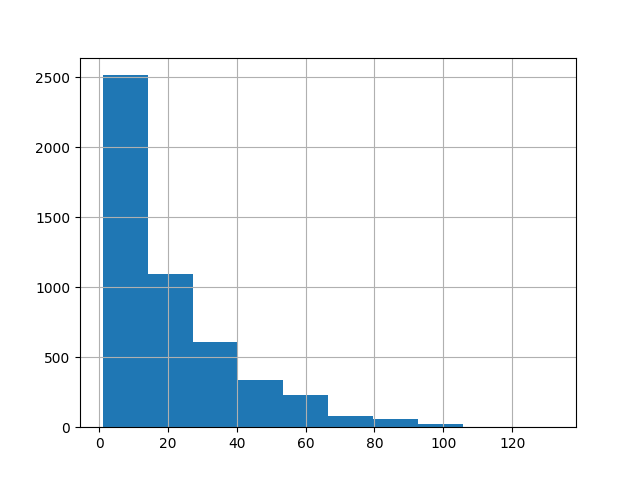

In [10]:
targets_sr.hist()

## Traits

#### Load traits

In [4]:
traits = pd.read_csv('~/Downloads/traits.csv', index_col=0)

iucn_stats = {s: traits['IUCN_category'].get(s, 'NA') for s in predictions.columns}
iucn_encr = pd.Series([(iucn_stats[s] in ['CR', 'EN'])*1 for s in predictions.columns], index = predictions.columns)

trop_level = {s: traits['Troph'].get(s, 'NA') for s in predictions.columns}
trop_troph = pd.Series([trop_level[s] if trop_level[s] != 'NA' else None for s in predictions.columns], index = predictions.columns)

iucnL_stats = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'NA') for s in predictions.columns}
iucnL_encr = pd.Series([(iucnL_stats[s] == 'Threatened')*1 for s in predictions.columns], index = predictions.columns)


#### Calculate F1

In [ ]:
baseline_aps = pd.read_csv(pred_path.parent / 'aps-sorted.csv', index_col = 0)

dic = {}

for s in baseline_aps.index:
    
    preds = (predictions[s] > THRESHOLD).astype(float).to_numpy().flatten()
    targ = (targets[s] != 0).astype(float).to_numpy().flatten()
    f1 = f1_score(targ, preds)
    dic[s] = {'f1': f1}

#### Associate to trait

In [ ]:
traitname = 'IUCN_category' # 'DemersPelag' 'Troph' 'IUCN_inferred_Loiseau23'

for s in baseline_aps.index:
    dic[s][traitname] = traits[traitname].get(s, 'NA')

df = pd.DataFrame(dic).T

In [7]:
df.sort_values(ascending=False, by = 'f1', inplace = True)
dg = df[:200]

#### Calculate composite indicators

In [8]:
def iucn_perc(row):
    present_species = row[row > THRESHOLD].index
    if len(present_species) == 0:
        return 0
    return iucnL_encr[present_species].sum() / len(present_species)

def av_troph(row):
    present_species = row[row > THRESHOLD].index
    if len(present_species) == 0:
        return 0
    return trop_troph[present_species].mean()

In [9]:
pred_iucn = predictions.apply(iucn_perc, axis=1)
target_iucn = targets.apply(iucn_perc, axis=1)
print(linregress(target_iucn, pred_iucn))

LinregressResult(slope=0.19530725593571677, intercept=0.029141215282289384, rvalue=0.2192006670749323, pvalue=5.922627394091089e-55, stderr=0.012354846563684962, intercept_stderr=0.0012921207862783039)


In [10]:
pred_trop = predictions.apply(av_troph, axis=1)
target_trop = targets.apply(av_troph, axis=1)

mask = ~np.isnan(target_trop) & ~np.isnan(pred_trop)

print(linregress(target_trop[mask], pred_trop[mask]))

LinregressResult(slope=0.1222899443679118, intercept=2.781070622380087, rvalue=0.10219485466040133, pvalue=5.684923681825179e-13, stderr=0.016920890881810667, intercept_stderr=0.05453029913641261)


<Axes: xlabel='None', ylabel='None'>

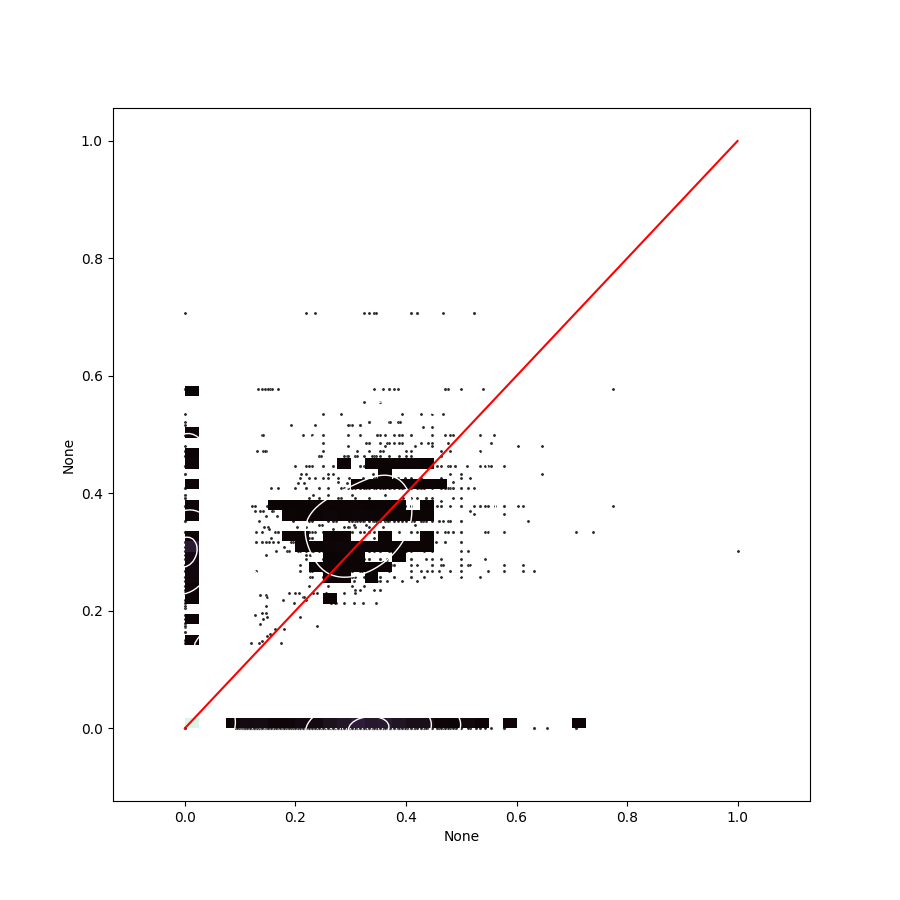

In [13]:
x, y = np.sqrt(target_iucn), np.sqrt(pred_iucn)
#x, y = target_trop, pred_trop

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

#### Plots

In [128]:
import plotly.express as px


fig = px.strip(df[df['f1'] > 0], x="dp", y="f1")
fig.update_layout(width=800, height=800)
fig.show()
